In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from timm import create_model
from torchmetrics.classification import Precision, Recall
import copy

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ✅ Check if GPU is available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
# ✅ Paths
train_dir = r"H:\My Drive\streenew10epoc\archive (5)\facesData\train"
test_dir = r"H:\My Drive\streenew10epoc\archive (5)\facesData\test"


In [4]:
# ✅ Image Preprocessing (Efficient for CPU)
img_size = 224  # Reduced 224x224 
batch_size = 32  # Optimized for 8GB RAM
num_epochs = 6

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to RGB
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # ✅ Now works for RGB
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to RGB
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # ✅ Now works for RGB
])


In [ ]:
# ✅ Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

# ✅ Data Loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


In [ ]:
# ✅ Load ViT model and modify the classifier for binary classification
model = create_model("vit_base_patch16_224", pretrained=True, num_classes=2)

# ✅ Modify the classifier layer to match 2 output classes
model.head = nn.Linear(model.head.in_features, 2)

# ✅ Move model to GPU (if available) or CPU
model = model.to(device)


In [10]:
# ✅ Training Loop
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs):
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        precision_metric.reset()
        recall_metric.reset()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Update precision & recall
            precision_metric.update(preds, labels)
            recall_metric.update(preds, labels)

        train_acc = 100 * correct / total
        train_loss /= len(train_loader)
        train_precision = precision_metric.compute().item()
        train_recall = recall_metric.compute().item()

        # ✅ Call scheduler before validation
        scheduler.step()
        
        # Dynamic LR adjustment after epoch 4
        if epoch > 4:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.1

        val_acc, val_loss = evaluate_model(model, test_loader, criterion)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Precision: {train_precision:.2f} | Recall: {train_recall:.2f}")
        print(f"  Val Loss: {val_loss:.4f}   | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    print(f"✅ Best validation accuracy: {best_acc:.2f}%")
    model.load_state_dict(best_model_wts)


In [11]:
# ✅ Evaluation Function
def evaluate_model(model, test_loader, criterion):
    model.eval()
    correct, total, total_loss = 0, 0, 0
    precision_metric.reset()  # ✅ Reset metrics
    recall_metric.reset()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # ✅ Update validation precision & recall
            precision_metric.update(preds, labels)
            recall_metric.update(preds, labels)

    val_precision = precision_metric.compute().item()
    val_recall = recall_metric.compute().item()
    
    avg_loss = total_loss / len(test_loader)
    print(f"  Validation Precision: {val_precision:.2f} | Validation Recall: {val_recall:.2f}")  # ✅ Log these values
    return 100 * correct / total, avg_loss

In [12]:
# ✅ Start Training
train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs)

  Validation Precision: 0.78 | Validation Recall: 0.65
Epoch [1/6]
  Train Loss: 0.5822 | Train Acc: 70.02% | Precision: 0.70 | Recall: 0.69
  Val Loss: 0.5406   | Val Acc: 73.05%
  Validation Precision: 0.82 | Validation Recall: 0.55
Epoch [2/6]
  Train Loss: 0.5114 | Train Acc: 74.74% | Precision: 0.75 | Recall: 0.74
  Val Loss: 0.5643   | Val Acc: 71.37%
  Validation Precision: 0.75 | Validation Recall: 0.76
Epoch [3/6]
  Train Loss: 0.4652 | Train Acc: 78.07% | Precision: 0.79 | Recall: 0.76
  Val Loss: 0.5154   | Val Acc: 74.90%
  Validation Precision: 0.74 | Validation Recall: 0.80
Epoch [4/6]
  Train Loss: 0.4189 | Train Acc: 80.79% | Precision: 0.82 | Recall: 0.79
  Val Loss: 0.5101   | Val Acc: 75.90%
  Validation Precision: 0.79 | Validation Recall: 0.74
Epoch [5/6]
  Train Loss: 0.3617 | Train Acc: 83.96% | Precision: 0.84 | Recall: 0.83
  Val Loss: 0.5244   | Val Acc: 76.83%
  Validation Precision: 0.78 | Validation Recall: 0.76
Epoch [6/6]
  Train Loss: 0.3135 | Train Acc:

In [ ]:

# Saving the model correctly after training
torch.save(model.state_dict(), "stress_detection_vit.pth")
print("✅ Model saved successfully!")


✅ Model saved successfully!


In [32]:
# Manually enter the training and validation metrics
epochs = [1, 2, 3, 4, 5, 6]

train_acc_list = [70.02, 74.74, 78.07, 80.79, 83.96, 86.72]
val_acc_list = [73.05, 71.37, 74.90, 75.90, 76.83, 77.23]

train_loss_list = [0.5822, 0.5114, 0.4652, 0.4189, 0.3617, 0.3135]
val_loss_list = [0.5406, 0.5643, 0.5154, 0.5101, 0.5244, 0.5241]


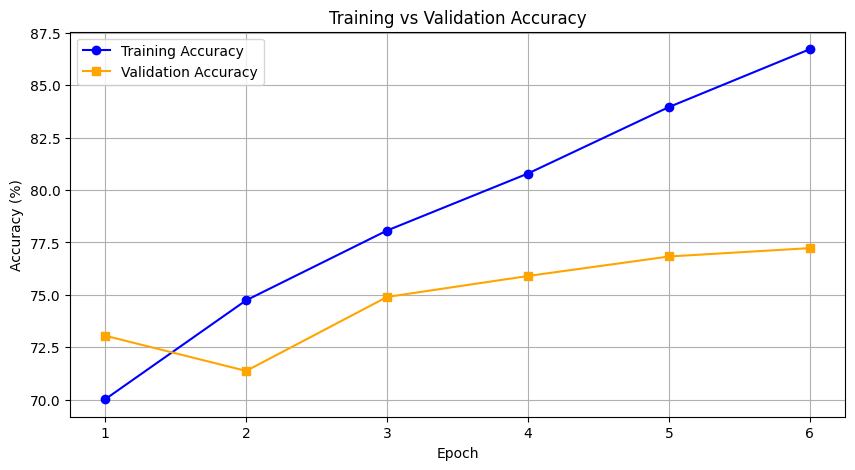

In [33]:
import matplotlib.pyplot as plt

# Plot Training vs Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc_list, label="Training Accuracy", marker='o', color='blue')
plt.plot(epochs, val_acc_list, label="Validation Accuracy", marker='s', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


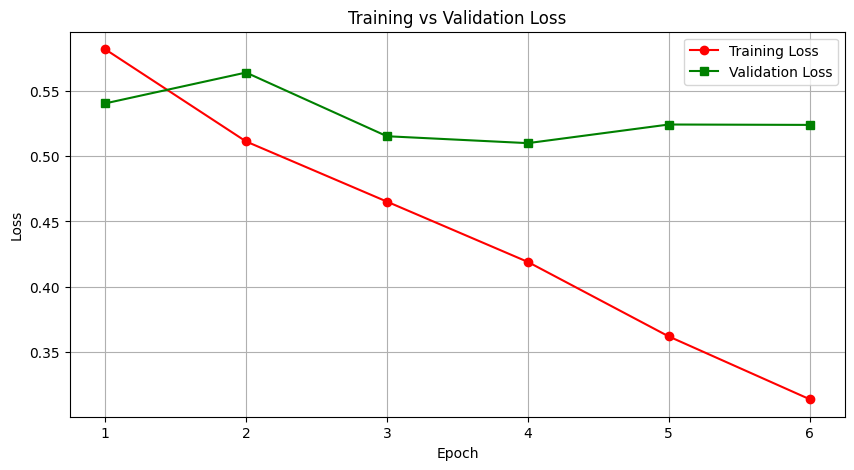

In [34]:
# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss_list, label="Training Loss", marker='o', color='red')
plt.plot(epochs, val_loss_list, label="Validation Loss", marker='s', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


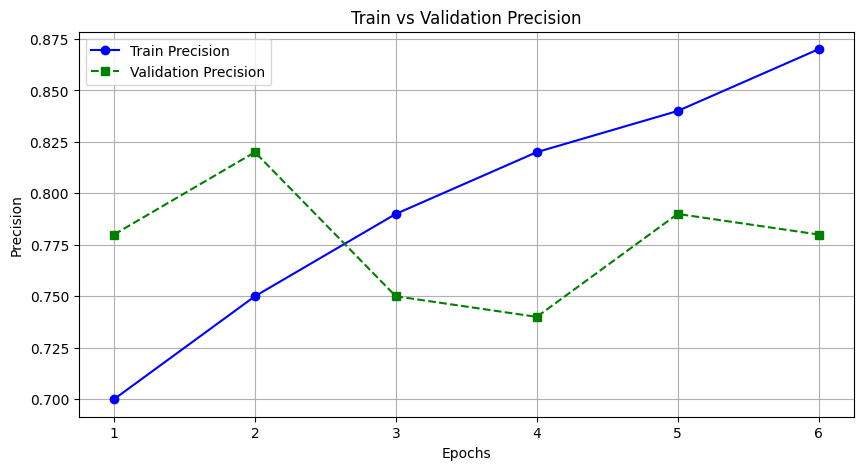

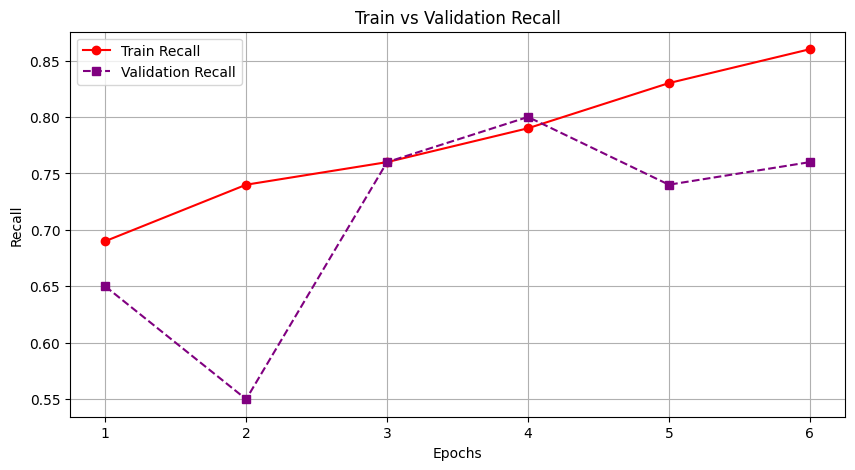

In [1]:
import matplotlib.pyplot as plt

# Sample epoch-wise precision and recall data
epochs = [1, 2, 3, 4, 5, 6]
train_precision = [0.70, 0.75, 0.79, 0.82, 0.84, 0.87]
train_recall = [0.69, 0.74, 0.76, 0.79, 0.83, 0.86]
val_precision = [0.78, 0.82, 0.75, 0.74, 0.79, 0.78]
val_recall = [0.65, 0.55, 0.76, 0.80, 0.74, 0.76]

# Plot Precision
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_precision, marker='o', linestyle='-', color='blue', label='Train Precision')
plt.plot(epochs, val_precision, marker='s', linestyle='--', color='green', label='Validation Precision')
plt.xlabel("Epochs")
plt.ylabel("Precision")
plt.title("Train vs Validation Precision")
plt.legend()
plt.grid(True)
plt.show()

# Plot Recall
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_recall, marker='o', linestyle='-', color='red', label='Train Recall')
plt.plot(epochs, val_recall, marker='s', linestyle='--', color='purple', label='Validation Recall')
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.title("Train vs Validation Recall")
plt.legend()
plt.grid(True)
plt.show()
